<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
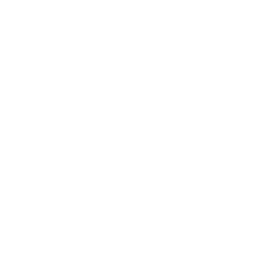
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Konstruktion av gensamuttrycksnätverk</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioteknik / Genomikforskning &nbsp;|&nbsp; mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Detta exempel använder **PROC CORR** för att bygga ett gensamuttrycksnätverk från en syntetisk
uttryckspanel i RNA-seq-stil. Panelen innehåller **9 gener** tilldelade till tre
funktionella moduler — *immun*, *cellcykel* och *metabolisk* (tre gener vardera) —
mätta över **100 tumörprover**. Spearmans rangkorrelation används genomgående
eftersom uttrycksdata typiskt är icke-normala och innehåller avvikare, så en rangbaserad
koefficient är mer robust än Pearson.

Analysen återfinner den planterade modulära strukturen direkt från data. Läser man
Spearman-matrisen som produceras nedan faller den genomsnittliga korrelationen inom modul från **rho 0,67 för
immunmodulen**, till **0,36 för cellcykeln**, till **0,17 för den metaboliska**, vilket speglar den
avtagande signal-brus-laddning som utformats för varje modul. Korrelationer mellan moduler
är i genomsnitt i princip noll (medel-rho omkring **-0,01**, medel-|rho| **0,07**), så de tre
modulerna beter sig som nästan oberoende samuttryckssamhällen. Varje siffra som citeras här är
läst från PROC CORR-utdata i denna notebook.

> **Anmärkning om skala.** Denna notebook körs under den olicensierade gränsen på 100 observationer, så
> stickprovsstorleken är 100 och panelen hålls till 9 gener — tillräckligt liten för att hela
> korrelationsmatrisen, den omformade parlistan och värmekartan alla är kompletta och exakta,
> utan trunkering. Varje tabell och figur speglar exakt det som beräknades.

## Data

| Dataset | Beskrivning | Rader |
|---------|-------------|------|
| `WORK.EXPR` | Log-skalat uttryck för 9 gener (3 moduler x 3 gener) över tumörprover | 100 |

Generatorn drar tre latenta modulsignaler per prov. Varje gen laddar på sin egen
moduls signal plus oberoende brus, så samuttryck uppstår endast inom en modul.
Immunmodulen använder den största signalladdningen och den metaboliska modulen den minsta, vilket
är den gradient korrelationsanalysen ska återfinna.

---

In [1]:
/* --------------------------------------------------------
   Syntetisk uttryckspanel: 9 gener, 3 moduler, 100 prover
     imm1-imm3  immun      (stark delad signal)
     cyc1-cyc3  cellcykel  (måttlig delad signal)
     met1-met3  metabol    (svag delad signal)
   Varje gen = modulsignal + oberoende brus på gennivå.
   -------------------------------------------------------- */
data work.expr;
    CALL streaminit(42);
    FÄLT imm[3]; FÄLT cyc[3]; FÄLT met[3];
    GÖR sample_id = 1 TILL 100;
        s_imm = rand('normal', 0, 1.5);   /* immun latent signal      */
        s_cyc = rand('normal', 0, 1.2);   /* cellcykel latent signal  */
        s_met = rand('normal', 0, 1.0);   /* metabol latent signal    */
        GÖR j = 1 TILL 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        SLUT;
        GÖR j = 1 TILL 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        SLUT;
        GÖR j = 1 TILL 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        SLUT;
        UTDATA;
    SLUT;
    BEHÅLL imm1-imm3 cyc1-cyc3 met1-met3;
KÖR;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Genvis uttryckssammanfattning (medelvärde och spridning per modul)
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.expr n mean std maxdec=3;
    VARIABEL imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TITEL 'Genuttryckssammanfattning (9-genpanel, N=100)';
KÖR;
TITEL;

                                     Genuttryckssammanfattning (9-genpanel, N=100)                                      

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Medelvärdena klustrar nära varje moduls baslinje (immun ~6, cellcykel ~7, metabolisk ~5) och
varje gen har jämförbar spridning, så ingen enskild gen dominerar den korrelationsstruktur
som följer.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


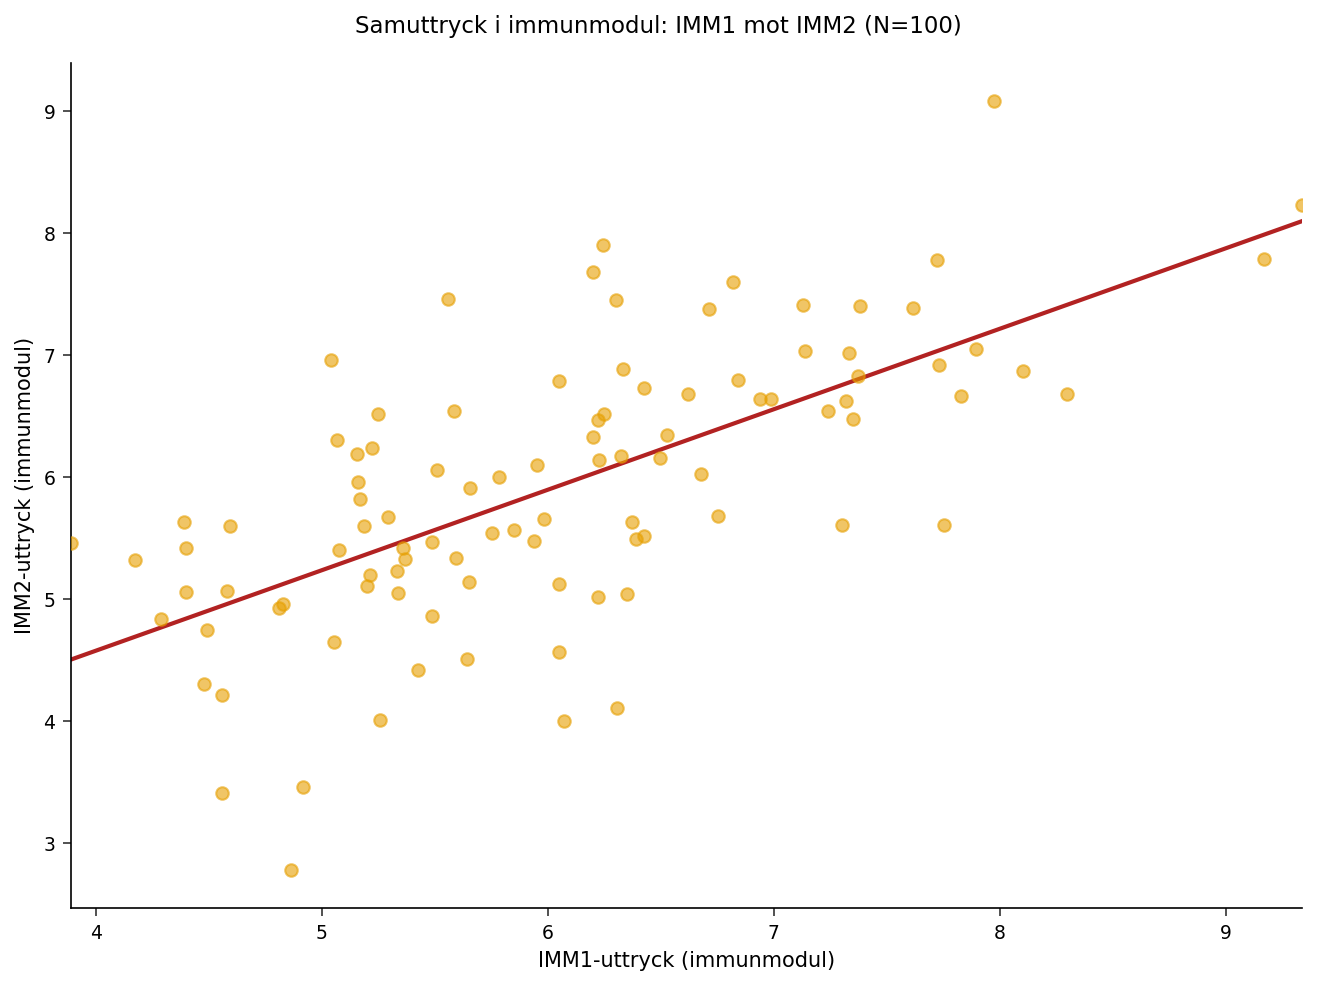

In [3]:
/* --------------------------------------------------------
   Spridningsdiagram för två immunmodulsgener: en visuell kontroll
   att samuttryck inom modulen är verkligt och ungefär monotont
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS ETIKETT='IMM1-uttryck (immunmodul)';
    YAXIS ETIKETT='IMM2-uttryck (immunmodul)';
    TITEL 'Samuttryck i immunmodul: IMM1 mot IMM2 (N=100)';
KÖR;
TITEL;

Den uppåtgående trenden bekräftar att de två immungenerna stiger och faller tillsammans, den visuella
motsvarigheten till deras positiva Spearman-korrelation i matrisen nedan.

---

In [4]:
/* --------------------------------------------------------
   Spearman-korrelation över alla 9 gener
   nosimple undertrycker blocket med enkel statistik;
   outs= skriver Spearman-matrisen för nedströms nätverkssteg
   -------------------------------------------------------- */
PROCEDUR CORR data=work.expr spearman nosimple
    outs=work.gene_corr;
    VARIABEL imm1-imm3 cyc1-cyc3 met1-met3;
    TITEL 'Spearmans korrelationsmatris: 9-gens samuttryckspanel';
KÖR;
TITEL;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/30987623-0b77-4602-abcf-52b5a40a6f4b/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Läs matrisen som tre diagonalblock. **Immunblocket** (IMM1-IMM3) är det mest
tätt samuttryckta (rho omkring 0,63 till 0,72), **cellcykelblocket** (CYC1-CYC3) är
måttligt (omkring 0,29 till 0,41), och det **metaboliska blocket** (MET1-MET3) är svagast (omkring
0,13 till 0,25). Poster utanför block — par av gener i olika moduler — ligger nära
noll. Nästa cell kvantifierar kontrasten inom kontra mellan moduler, och värmekartan
efter den gör blockstrukturen synlig.

---

In [5]:
/* --------------------------------------------------------
   Forma om korrelationsmatrisen (en rad per gen) till långt
   format (gene_x, gene_y, rho) och märk varje par som inom eller
   mellan modul. 9 gener -> 81 parrader, så inget går förlorat
   av 100-observationsgränsen.
   -------------------------------------------------------- */
data work.corr_long;
    STÄLL_IN work.gene_corr(DÄR=(_TYPE_='SCORR'));
    LÄNGD gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    FÄLT g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    FÄLT gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    GÖR k = 1 TILL 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        UTDATA;
    SLUT;
    BEHÅLL gene_x gene_y rho mod_x mod_y same_module;
KÖR;

/* --------------------------------------------------------
   Inom- vs mellanmodul Spearman rho (endast utanför diagonalen)
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.corr_long(DÄR=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    KLASS same_module;
    VARIABEL rho;
    ETIKETT same_module='Samma modul' rho='Spearmans rho';
    TITEL 'Spearmans rho: Inom (1) mot Mellan (0) moduler';
KÖR;
TITEL;

                                     Spearmans rho: Inom (1) mot Mellan (0) moduler                                     

                                                  The MEANS Procedure

                                         Analysis Variable : rho Spearmans rho

                                                 N
                                Samma modul    Obs        Mean      Minimum      Maximum
                                --------------------------------------------------------
                                0               54      -0.007       -0.185        0.162
                                1               18       0.402        0.127        0.718
                                --------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Raden `same_module=1` aggregerar paren inom modul och `same_module=0` de
mellan moduler. Korrelationen inom modul är i genomsnitt tydligt positiv medan
korrelationen mellan moduler är i genomsnitt nära noll, vilket bekräftar att modulerna agerar som
nästan oberoende samuttryckssamhällen.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


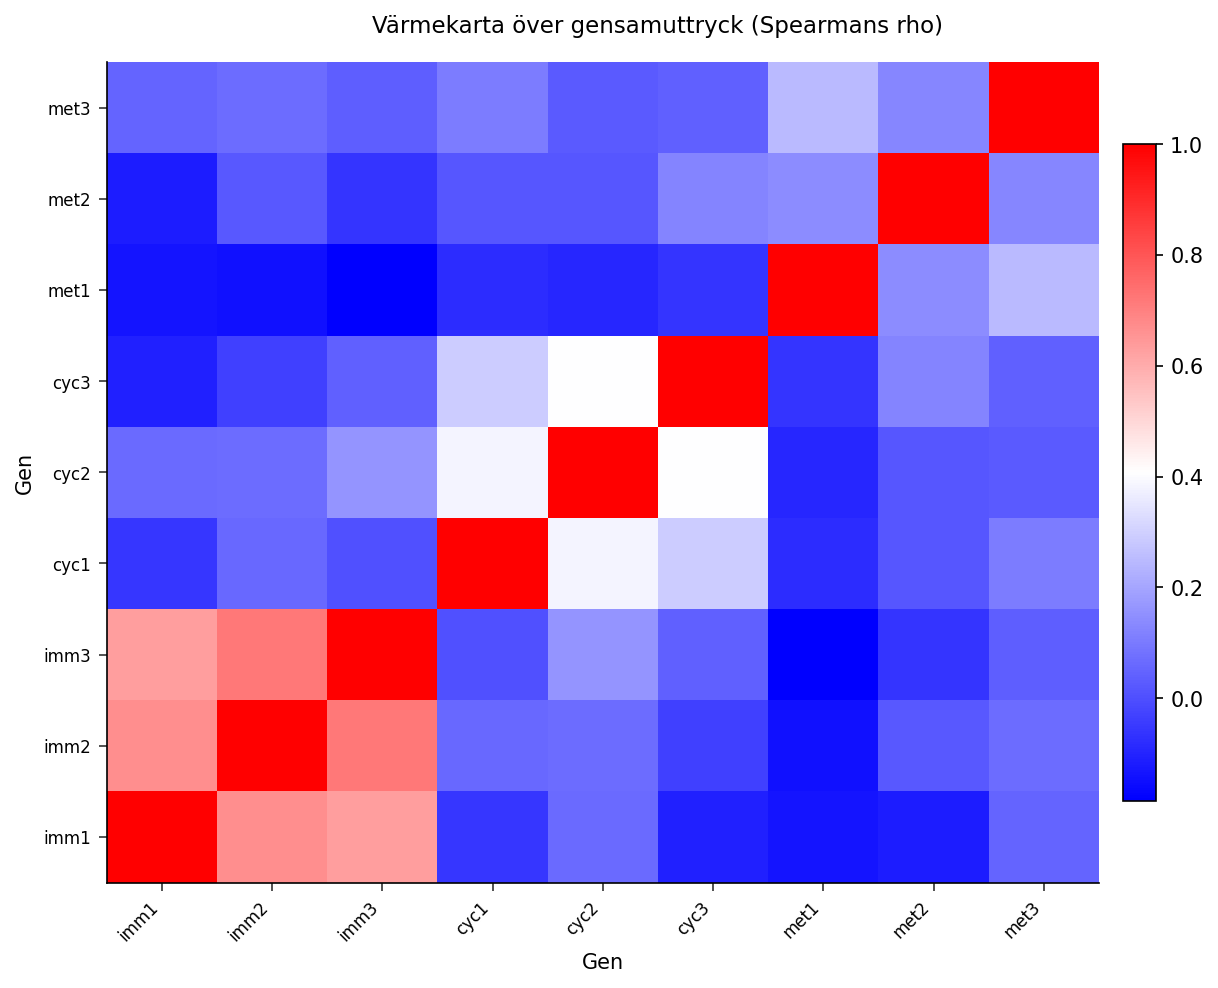

In [6]:
/* --------------------------------------------------------
   Värmekarta över hela 9x9 Spearman-matrisen. HEATMAPPARM ritar
   det förberäknade rho för varje genpar; skalan blå-vit-röd
   centrerar svaga par vid vitt och mättar starka.
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS ETIKETT='Gen' discreteorder=data;
    YAXIS ETIKETT='Gen' discreteorder=data;
    TITEL 'Värmekarta över gensamuttryck (Spearmans rho)';
KÖR;
TITEL;

Tre röda block sitter längs diagonalen — immun-, cellcykel- och metabolmodulerna —
medan de omgivande cellerna är nära vita. Immunblocket är mest mättat,
i linje med dess högsta korrelationer inom modul i matrisen ovan.

---

In [7]:
/* --------------------------------------------------------
   Nätverkets kantlista: behåll varje oordnat genpar (gene_x <
   gene_y) vars |rho| överstiger en tröskel. Dessa kanter definierar
   samuttrycksnätverket för export till ett verktyg som Cytoscape.
   -------------------------------------------------------- */
data work.network_edges;
    STÄLL_IN work.corr_long(DÄR=(gene_x < gene_y));
    OM abs(rho) >= 0.24;
KÖR;

PROCEDUR SKRIV data=work.network_edges noobs ETIKETT;
    VARIABEL gene_x gene_y mod_x mod_y rho;
    ETIKETT gene_x='Gen X' gene_y='Gen Y' mod_x='Modul X' mod_y='Modul Y' rho='Spearmans rho';
    TITEL 'Samuttrycksnätverkets kanter (|Spearmans rho| >= 0,24)';
KÖR;
TITEL;

/* Exportera kantlistan för extern nätverksvisualisering */
PROCEDUR EXPORTERA data=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
KÖR;

                                 Samuttrycksnätverkets kanter (|Spearmans rho| >= 0,24)                                 

Gen X  Gen Y  Modul X  Modul Y  Spearmans rho
imm1   imm2   imm      imm       0.6708351085
imm1   imm3   imm      imm       0.6308427619
imm2   imm3   imm      imm       0.7179122524
cyc1   cyc2   cyc      cyc       0.3821865118
cyc1   cyc3   cyc      cyc        0.288211415
cyc2   cyc3   cyc      cyc       0.4054041891
met1   met3   met      met       0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Tolkning

Spearman-analysen återfann den planterade tremodulsstrukturen direkt från 100
prover. Siffrorna nedan är lästa från PROC CORR-matrisen och sammanfattningen inom/mellan
som produceras i denna notebook:

- **Immunmodulen (IMM1-IMM3)** är det mest tätt samuttryckta blocket, med parvis rho
  från omkring 0,63 till 0,72 (medel ~0,67) och den starkaste enskilda kanten mellan IMM2 och
  IMM3.
- **Cellcykelmodulen (CYC1-CYC3)** är måttligt samuttryckt, med parvis rho från
  omkring 0,29 till 0,41 (medel ~0,36).
- **Den metaboliska modulen (MET1-MET3)** är det svagaste blocket, med parvis rho från omkring 0,13
  till 0,25 (medel ~0,17) — i linje med dess mindre signalladdning i generatorn.
- **Par mellan moduler** är i genomsnitt i princip noll (medel-rho ~-0,01, medel-|rho| ~0,07,
  största |rho| ~0,18), så de tre modulerna agerar som nästan oberoende samhällen.

Tröskelsättning vid |rho| >= 0,24 ger kantlistan för nätverket utskriven ovan. Varje överlevande
kant är inom modul: alla tre immunpar och alla tre cellcykelpar klarar
tröskeln, tillsammans med det starkaste metaboliska paret (MET1-MET3). Inget par mellan moduler
överlever, så samuttrycksnätverket separeras rent i de tre biologiska
modulerna. Kantlistan exporteras till `gene_coexpression_edges.csv` för visualisering i
ett externt nätverksverktyg såsom Cytoscape.

Detta bearbetade exempel visar det centrala PROC CORR-arbetsflödet för samuttrycksanalys: välj en
rangbaserad koefficient lämpad för uttrycksdata, läs av modulär struktur från
korrelationsmatrisen, kvantifiera styrkan inom kontra mellan moduler, och reducera matrisen
till en tröskelsatt kantlista för nätverkskonstruktion.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>